In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Times New Roman'

In [146]:
df = pd.read_csv('FutureModelPredictionData.csv')
df

,year,state_po,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_president,midterm,republican_incumbent,pvi,Republican Prob
0,2026,AL,1,27.72,41.1,4.0,63.8,26.1,0.5,1.6,True,True,True,27.0,0.999903
1,2026,AL,2,25.70,39.0,5.2,58.8,30.3,0.2,1.4,True,True,False,-5.0,0.006033
2,2026,AL,3,25.79,40.1,4.2,67.0,23.2,0.2,1.6,True,True,True,23.0,0.999617
3,2026,AL,4,20.50,40.8,8.1,80.6,6.3,0.3,0.8,True,True,True,33.0,0.999990
4,2026,AL,5,38.20,39.4,7.0,68.6,17.4,0.3,2.0,True,True,True,15.0,0.992693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,2026,WI,5,41.55,43.0,6.0,85.9,1.8,0.1,3.0,True,True,True,11.0,0.973789
431,2026,WI,6,30.01,42.7,6.0,86.0,2.0,0.3,2.6,True,True,True,8.0,0.937804
432,2026,WI,7,26.71,45.3,3.0,89.4,0.4,1.6,1.5,True,True,True,11.0,0.978465
433,2026,WI,8,29.29,41.5,6.7,83.7,1.5,1.8,2.5,True,True,True,8.0,0.926590


## Simulating 2026 Outcomes

In [147]:
num_simulations = 50000
simulationDict = {
    'Republican Seats' : [],
    'Democratic Seats' : []
}
np.random.seed(28)

for _ in range(num_simulations):
    randomNum = np.random.rand()
    numWins = (df['Republican Prob'] > randomNum).sum()
    numLosses = 435 - numWins
    simulationDict['Republican Seats'].append(numWins)
    simulationDict['Democratic Seats'].append(numLosses)

simulationDF = pd.DataFrame(simulationDict)

winCount = (simulationDF['Republican Seats'] >= 218).sum()
republicanProb = (winCount/num_simulations) * 100
democraticProb = 100 - republicanProb

print("Democrats have a ", democraticProb, "% chance of flipping the House of Representatives.")
print("Republicans have a ", republicanProb, "% chance of holding the House of Representatives.")


Democrats have a  65.134 % chance of flipping the House of Representatives.
Republicans have a  34.866 % chance of holding the House of Representatives.


In [148]:
simulationDF['Margin'] = simulationDF['Republican Seats'] - simulationDF['Democratic Seats']
print('Democratic Mode: ', simulationDF['Democratic Seats'].mode())
print('Republican Mode: ',simulationDF['Republican Seats'].mode())
simulationDF.describe()
#simulationDF

Democratic Mode:  0    216
Name: Democratic Seats, dtype: int64
Republican Mode:  0    219
Name: Republican Seats, dtype: int64


,Republican Seats,Democratic Seats,Margin
count,50000.000000,50000.000000,50000.000000
mean,202.011420,232.988580,-30.977160
std,30.395482,30.395482,60.790964
min,0.000000,44.000000,-435.000000
25%,194.000000,216.000000,-47.000000
50%,211.000000,224.000000,-13.000000
75%,219.000000,241.000000,3.000000
max,391.000000,435.000000,347.000000


## Forecast Visualizations

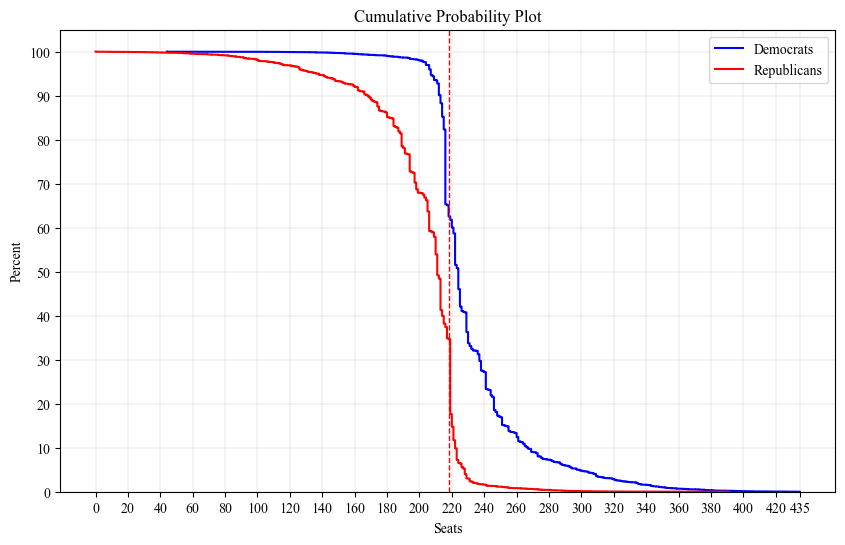

In [149]:
fig, ax = plt.subplots(figsize=(10,6))
sns.ecdfplot(data=simulationDF['Democratic Seats'], stat='percent', complementary=True, label= 'Democrats', color='blue', ax=ax)
sns.ecdfplot(data=simulationDF['Republican Seats'], stat='percent', complementary=True, label='Republicans', color='red', ax=ax)
ax.set_xticks([0,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300,320,340,360,380,400,420,435])
ax.set_yticks([0,10,20,30,40,50,60,70,80,90,100])
plt.title('Cumulative Probability Plot')
plt.xlabel('Seats')
plt.grid(True, linewidth = 0.2)
plt.legend()
plt.axvline(x=218, color='red', linestyle='--', linewidth=1)
plt.show()

## District Ratings

In [150]:
filteredDF = df[(df['Republican Prob'] < 0.9) & (df['Republican Prob'] > 0.1)]
filteredDF = filteredDF.drop(['year', 'CollegeGrad', 'MedianAge', 'Hispanic', 'White', 'Black', 'NativeAmerican', 'Asian', 'republican_president', 'midterm'], axis=1)
filteredDF

,state_po,district,republican_incumbent,pvi,Republican Prob
7,AK,0,True,6.0,0.592358
8,AZ,1,True,1.0,0.482613
9,AZ,2,True,7.0,0.726005
13,AZ,6,True,0.0,0.539073
23,CA,3,True,2.0,0.589025
42,CA,22,True,1.0,0.678797
60,CA,40,True,1.0,0.372015
61,CA,41,True,2.0,0.675248
68,CA,48,True,7.0,0.898601
75,CO,3,True,5.0,0.865393


In [151]:
def rating(prob):
    if 0.1 <= prob < 0.25:
        return "Likely D"
    elif 0.25 <= prob < 0.4:
        return "Lean D"
    elif 0.4 <= prob < 0.5:
        return "Tilt D"
    elif 0.5 <= prob < 0.6:
        return "Tilt R"
    elif 0.6 <= prob < 0.75:
        return "Lean R"
    else:
        return "Likely R"

In [152]:
filteredDF['Rating'] = filteredDF['Republican Prob'].apply(rating)
filteredDF

,state_po,district,republican_incumbent,pvi,Republican Prob,Rating
7,AK,0,True,6.0,0.592358,Tilt R
8,AZ,1,True,1.0,0.482613,Tilt D
9,AZ,2,True,7.0,0.726005,Lean R
13,AZ,6,True,0.0,0.539073,Tilt R
23,CA,3,True,2.0,0.589025,Tilt R
42,CA,22,True,1.0,0.678797,Lean R
60,CA,40,True,1.0,0.372015,Lean D
61,CA,41,True,2.0,0.675248,Lean R
68,CA,48,True,7.0,0.898601,Likely R
75,CO,3,True,5.0,0.865393,Likely R


In [153]:
ratingDF = filteredDF.drop(['pvi'], axis=1)
ratingDF['district'] = ratingDF['district'].astype(str)
ratingDF['District'] = ratingDF['state_po'] + '-' + ratingDF['district']
ratingDF = ratingDF.drop(['state_po', 'district'], axis=1)
ratingDF.to_csv('2026Ratings.csv', index=False)
ratingDF

,republican_incumbent,Republican Prob,Rating,District
7,True,0.592358,Tilt R,AK-0
8,True,0.482613,Tilt D,AZ-1
9,True,0.726005,Lean R,AZ-2
13,True,0.539073,Tilt R,AZ-6
23,True,0.589025,Tilt R,CA-3
42,True,0.678797,Lean R,CA-22
60,True,0.372015,Lean D,CA-40
61,True,0.675248,Lean R,CA-41
68,True,0.898601,Likely R,CA-48
75,True,0.865393,Likely R,CO-3


In [154]:
safeD = df[df['Republican Prob'] <= 0.1]
safeD

,year,state_po,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_president,midterm,republican_incumbent,pvi,Republican Prob
1,2026,AL,2,25.70,39.0,5.2,58.8,30.3,0.2,1.4,True,True,False,-5.0,0.006033
6,2026,AL,7,24.31,36.9,4.5,36.0,55.2,0.2,1.3,True,True,False,-13.0,0.000343
10,2026,AZ,3,20.61,31.5,62.6,19.4,11.0,1.2,2.2,True,True,False,-22.0,0.000022
11,2026,AZ,4,40.14,35.8,29.2,52.7,4.9,1.8,5.8,True,True,False,-4.0,0.005712
14,2026,AZ,7,22.29,34.1,60.3,28.6,3.5,2.5,1.8,True,True,False,-13.0,0.000479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,2026,WA,8,41.97,40.0,12.0,64.8,2.0,0.9,11.6,True,True,False,-3.0,0.006676
422,2026,WA,9,43.57,38.0,14.7,39.3,12.6,0.2,23.3,True,True,False,-22.0,0.000005
423,2026,WA,10,34.67,37.3,14.0,58.1,7.0,0.8,7.6,True,True,False,-9.0,0.001031
427,2026,WI,2,47.48,37.4,7.2,78.6,4.4,0.1,5.0,True,True,False,-21.0,0.000015


In [155]:
safeR = df[df['Republican Prob'] >= 0.9]
safeR

,year,state_po,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_president,midterm,republican_incumbent,pvi,Republican Prob
0,2026,AL,1,27.72,41.1,4.0,63.8,26.1,0.5,1.6,True,True,True,27.0,0.999903
2,2026,AL,3,25.79,40.1,4.2,67.0,23.2,0.2,1.6,True,True,True,23.0,0.999617
3,2026,AL,4,20.50,40.8,8.1,80.6,6.3,0.3,0.8,True,True,True,33.0,0.999990
4,2026,AL,5,38.20,39.4,7.0,68.6,17.4,0.3,2.0,True,True,True,15.0,0.992693
5,2026,AL,6,39.23,39.8,6.9,68.1,19.5,0.1,1.8,True,True,True,20.0,0.998732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,2026,WI,5,41.55,43.0,6.0,85.9,1.8,0.1,3.0,True,True,True,11.0,0.973789
431,2026,WI,6,30.01,42.7,6.0,86.0,2.0,0.3,2.6,True,True,True,8.0,0.937804
432,2026,WI,7,26.71,45.3,3.0,89.4,0.4,1.6,1.5,True,True,True,11.0,0.978465
433,2026,WI,8,29.29,41.5,6.7,83.7,1.5,1.8,2.5,True,True,True,8.0,0.926590
